In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes_data.csv to diabetes_data.csv


In [ ]:
import pandas as pd

df = pd.read_csv("diabetes_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (3000, 36)


,Unnamed: 0,Fasting_Blood_Glucose,Postprandial_Blood_Glucose,HbA1c,Random_Blood_Glucose,BMI,Waist_Circumference,Triglyceride_Levels,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Gestational_Diabetes,PCOS,Hypertension,Physical_Activity,Smoking,Alcohol_Consumption,Obesity,Diet,Sleep_Apnea,Diabetes_Status
0,0,118.690215,111.472598,5.570234,224.721689,29.299897,37.872710,212.064239,93.491951,100.418755,...,Yes,No,Yes,Yes,No,Yes,No,No,No,Positive
1,1,193.592860,172.123161,5.481873,253.236721,35.135808,39.468713,93.096591,106.809528,98.109810,...,Yes,No,No,No,Yes,No,No,Yes,No,Negative
2,2,165.159212,228.400792,9.437527,127.607617,34.004023,47.090948,268.098641,164.812122,56.702794,...,No,No,No,Yes,Yes,No,Yes,No,No,Positive
3,3,147.825603,204.478231,5.497277,213.721043,18.847498,36.800088,203.279060,159.009152,114.580068,...,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Positive
4,4,90.282423,217.115395,5.631698,201.501576,18.731237,47.392994,89.300971,121.557842,89.793054,...,Yes,Yes,No,Yes,No,Yes,No,Yes,Yes,Positive


In [ ]:
# STEP 2: Clean and inspect the dataset

# Remove unnecessary index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget values:")
print(df["Diabetes_Status"].value_counts(dropna=False))

Dataset shape: (3000, 35)

Column names:
['Fasting_Blood_Glucose', 'Postprandial_Blood_Glucose', 'HbA1c', 'Random_Blood_Glucose', 'BMI', 'Waist_Circumference', 'Triglyceride_Levels', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'LDL_Cholesterol', 'HDL_Cholesterol', 'CRP_Levels', 'Insulin_Levels', 'HOMA_IR', 'OGTT', 'Creatinine_Levels', 'eGFR', 'Microalbuminuria', 'Uric_Acid_Levels', 'Fructosamine_Levels', 'ALT', 'AST', 'C_Peptide', 'Proinsulin_Levels', 'Family_History_of_Diabetes', 'Gestational_Diabetes', 'PCOS', 'Hypertension', 'Physical_Activity', 'Smoking', 'Alcohol_Consumption', 'Obesity', 'Diet', 'Sleep_Apnea', 'Diabetes_Status']

Missing values:
0

Duplicate rows:
0

Target values:
Diabetes_Status
Positive    1664
Negative    1336
Name: count, dtype: int64


In [ ]:
# STEP 3: Prepare the target variable

print("Original target values:")
print(df["Diabetes_Status"].unique())

# Convert target into 0 = Negative, 1 = Positive
if df["Diabetes_Status"].dtype == "object":
    target_mapping = {
        "Negative": 0,
        "Positive": 1
    }

    df["Target"] = df["Diabetes_Status"].map(target_mapping)

else:
    df["Target"] = df["Diabetes_Status"].astype(int)

print("\nEncoded target distribution:")
print(df["Target"].value_counts())

print("\nTarget data type:")
print(df["Target"].dtype)

# Check whether any values failed to map
print("\nMissing target values after encoding:",
      df["Target"].isnull().sum())

Original target values:
['Positive' 'Negative']

Encoded target distribution:
Target
1    1664
0    1336
Name: count, dtype: int64

Target data type:
int64

Missing target values after encoding: 0


In [ ]:
# STEP 4: Select features for the diabetes screening model

screening_features = [
    "BMI",
    "Waist_Circumference",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Family_History_of_Diabetes",
    "Hypertension",
    "Physical_Activity",
    "Smoking",
    "Alcohol_Consumption",
    "Obesity",
    "PCOS",
    "Gestational_Diabetes"
]

# Check whether all selected features exist
missing_features = [
    feature for feature in screening_features
    if feature not in df.columns
]

print("Missing screening features:", missing_features)

print("\nNumber of screening features:", len(screening_features))

print("\nSelected screening features:")
for i, feature in enumerate(screening_features, 1):
    print(f"{i}. {feature}")

Missing screening features: []

Number of screening features: 12

Selected screening features:
1. BMI
2. Waist_Circumference
3. Blood_Pressure_Systolic
4. Blood_Pressure_Diastolic
5. Family_History_of_Diabetes
6. Hypertension
7. Physical_Activity
8. Smoking
9. Alcohol_Consumption
10. Obesity
11. PCOS
12. Gestational_Diabetes


In [ ]:
# STEP 5: Create features and split the dataset

from sklearn.model_selection import train_test_split

# Input features
X = df[screening_features].copy()

# Target
y = df["Target"].copy()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 2400
Testing samples: 600

Training feature shape: (2400, 12)
Testing feature shape: (600, 12)

Training target distribution:
Target
1    1331
0    1069
Name: count, dtype: int64

Testing target distribution:
Target
1    333
0    267
Name: count, dtype: int64


In [ ]:
# STEP 6: Create the preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Identify numerical and categorical features
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("\nPreprocessing pipeline created successfully!")

Numerical features:
['BMI', 'Waist_Circumference', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic']

Categorical features:
['Family_History_of_Diabetes', 'Hypertension', 'Physical_Activity', 'Smoking', 'Alcohol_Consumption', 'Obesity', 'PCOS', 'Gestational_Diabetes']

Preprocessing pipeline created successfully!


In [ ]:
# STEP 7: Train Logistic Regression, Random Forest and XGBoost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --------------------------------------------------
# 1. Logistic Regression
# --------------------------------------------------

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# --------------------------------------------------
# 2. Random Forest
# --------------------------------------------------

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    ))
])


# --------------------------------------------------
# 3. XGBoost
# --------------------------------------------------

xgb_classifier = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric="logloss"
)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_classifier)
])


# --------------------------------------------------
# Train all three models
# --------------------------------------------------

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("\n✅ All three models trained successfully!")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

✅ All three models trained successfully!


In [ ]:
# STEP 8: Evaluate and compare the three models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, model):
    # Predictions
    y_pred = model.predict(X_test)

    # Probability of Positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1-Score": f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return results, y_pred, y_prob


# Evaluate Logistic Regression
results_lr, pred_lr, prob_lr = evaluate_model(
    "Logistic Regression",
    lr_model
)

# Evaluate Random Forest
results_rf, pred_rf, prob_rf = evaluate_model(
    "Random Forest",
    rf_model
)

# Evaluate XGBoost
results_xgb, pred_xgb, prob_xgb = evaluate_model(
    "XGBoost",
    xgb_model
)


# Create comparison table
results_df = pd.DataFrame([
    results_lr,
    results_rf,
    results_xgb
])

print("MODEL PERFORMANCE COMPARISON")
display(results_df.round(4))

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8967,0.9094,0.9039,0.9066,0.9465
1,Random Forest,0.8967,0.8883,0.9309,0.9091,0.9658
2,XGBoost,0.9033,0.8986,0.9309,0.9145,0.9640


Confusion Matrix:
[[232  35]
 [ 23 310]]


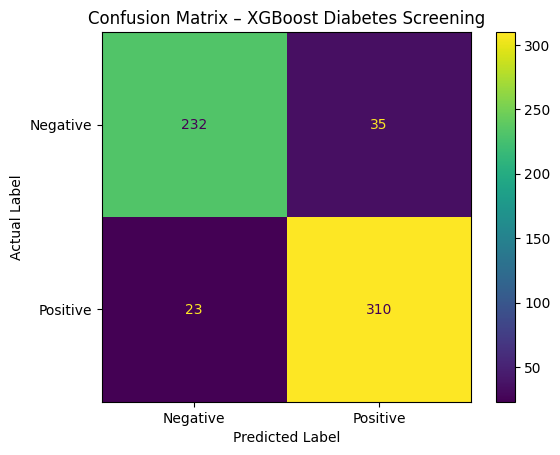

In [ ]:
# STEP 9A: Confusion Matrix for XGBoost

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, pred_xgb)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(values_format="d")

plt.title("Confusion Matrix – XGBoost Diabetes Screening")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

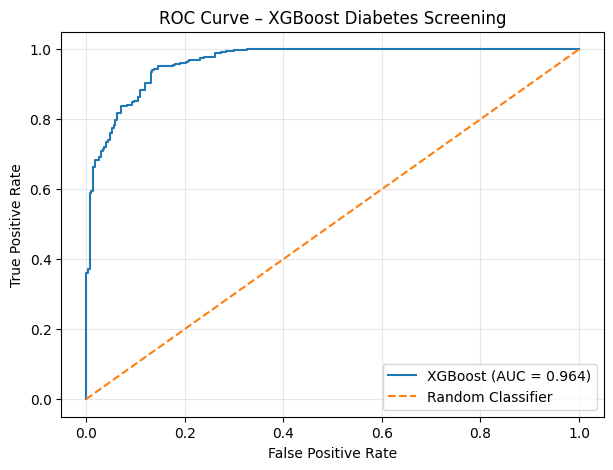

ROC-AUC Score: 0.9640


In [ ]:
# STEP 9B: ROC Curve for XGBoost

from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, prob_xgb)

# Calculate AUC
auc_score = roc_auc_score(y_test, prob_xgb)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc_score:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost Diabetes Screening")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [ ]:
# STEP 10A: Prepare data for SHAP explainability

import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the preprocessing part of the trained XGBoost pipeline
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Get the actual trained XGBoost classifier
xgb_estimator = xgb_model.named_steps["model"]

# Transform the test data using the same preprocessing
X_test_transformed = xgb_preprocessor.transform(X_test)

# Convert sparse matrix to dense matrix if required
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get the transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Create a DataFrame for SHAP
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

print("SHAP data shape:", X_test_shap.shape)
print("\nTransformed features:")
print(feature_names)

SHAP data shape: (600, 20)

Transformed features:
['num__BMI' 'num__Waist_Circumference' 'num__Blood_Pressure_Systolic'
 'num__Blood_Pressure_Diastolic' 'cat__Family_History_of_Diabetes_No'
 'cat__Family_History_of_Diabetes_Yes' 'cat__Hypertension_No'
 'cat__Hypertension_Yes' 'cat__Physical_Activity_No'
 'cat__Physical_Activity_Yes' 'cat__Smoking_No' 'cat__Smoking_Yes'
 'cat__Alcohol_Consumption_No' 'cat__Alcohol_Consumption_Yes'
 'cat__Obesity_No' 'cat__Obesity_Yes' 'cat__PCOS_No' 'cat__PCOS_Yes'
 'cat__Gestational_Diabetes_No' 'cat__Gestational_Diabetes_Yes']


In [ ]:
# STEP 10B: Create SHAP TreeExplainer

explainer = shap.TreeExplainer(xgb_estimator)

shap_values = explainer.shap_values(X_test_shap)

print("SHAP values generated successfully!")
print("SHAP values shape:", shap_values.shape)

SHAP values generated successfully!
SHAP values shape: (600, 20)


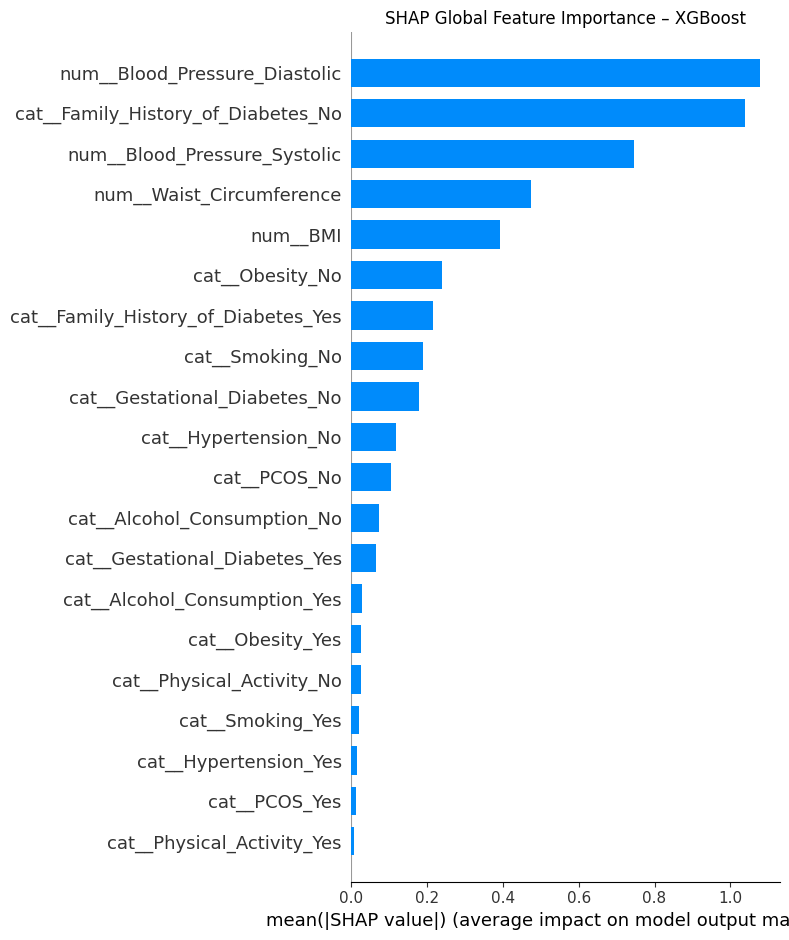

In [ ]:
# STEP 10C: SHAP Global Feature Importance

plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance – XGBoost")
plt.tight_layout()
plt.show()

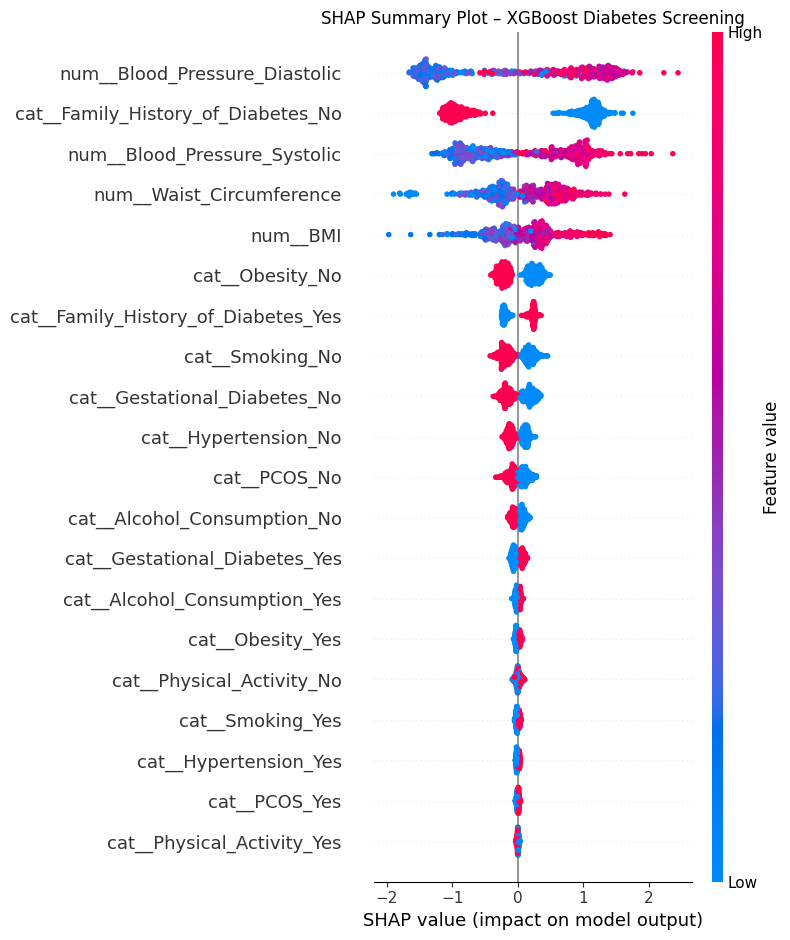

In [ ]:
# STEP 10D: Detailed SHAP Summary Plot

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_shap,
    show=False
)

plt.title("SHAP Summary Plot – XGBoost Diabetes Screening")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 11: Save the trained model and project files

import joblib
import os

# 1. Save the complete XGBoost pipeline
joblib.dump(
    xgb_model,
    "diabetes_screening_xgb_pipeline.pkl"
)

# 2. Save the screening feature list
joblib.dump(
    screening_features,
    "screening_features.pkl"
)

# 3. Save model performance results
results_df.to_csv(
    "model_performance_results.csv",
    index=False
)

print("✅ All project files saved successfully!")

print("\nSaved files:")
print("1. diabetes_screening_xgb_pipeline.pkl")
print("2. screening_features.pkl")
print("3. model_performance_results.csv")

✅ All project files saved successfully!

Saved files:
1. diabetes_screening_xgb_pipeline.pkl
2. screening_features.pkl
3. model_performance_results.csv


In [ ]:
# STEP 11B: Verify saved files

import os

files_to_check = [
    "diabetes_screening_xgb_pipeline.pkl",
    "screening_features.pkl",
    "model_performance_results.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"✅ {file}  |  {size:.2f} KB")
    else:
        print(f"❌ {file} NOT FOUND")

✅ diabetes_screening_xgb_pipeline.pkl  |  397.87 KB
✅ screening_features.pkl  |  0.23 KB
✅ model_performance_results.csv  |  0.37 KB


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.7 MB/s eta 0:00:00


In [ ]:
import streamlit
import sklearn
import xgboost
import shap
import joblib
import pandas
import numpy

print("Streamlit :", streamlit.__version__)
print("Scikit-learn :", sklearn.__version__)
print("XGBoost :", xgboost.__version__)
print("SHAP :", shap.__version__)
print("Joblib :", joblib.__version__)
print("Pandas :", pandas.__version__)
print("NumPy :", numpy.__version__)

Streamlit : 1.63.0
Scikit-learn : 1.6.1
XGBoost : 3.4.1
SHAP : 0.52.0
Joblib : 1.5.3
Pandas : 2.2.3
NumPy : 2.1.3


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PAGE CONFIGURATION
# ---------------------------------------------------------

st.set_page_config(
    page_title="AI-Based Diabetes Risk Screening",
    page_icon="🩺",
    layout="wide"
)

# ---------------------------------------------------------
# LOAD TRAINED MODEL
# ---------------------------------------------------------

@st.cache_resource
def load_model():
    model = joblib.load("diabetes_screening_xgb_pipeline.pkl")
    features = joblib.load("screening_features.pkl")
    return model, features


xgb_model, screening_features = load_model()

# ---------------------------------------------------------
# HEADER
# ---------------------------------------------------------

st.title("🩺 AI-Based Diabetes Risk Screening")

st.markdown(
    """
    ### Explainable Clinical Decision Support Prototype

    This research prototype uses machine learning to estimate
    diabetes screening risk from non-laboratory health and
    lifestyle indicators.
    """
)

st.info(
    "Research Prototype | Model: XGBoost | Explainability: SHAP"
)

# ---------------------------------------------------------
# SIDEBAR
# ---------------------------------------------------------

with st.sidebar:

    st.header("System Information")

    st.write("**Application:** Diabetes Risk Screening")
    st.write("**Model:** XGBoost")
    st.write("**Explainability:** SHAP")
    st.write("**Mode:** Screening")
    st.write("**Status:** Research Prototype")

    st.divider()

    st.caption(
        "Laboratory biomarkers such as HbA1c and fasting glucose "
        "are reserved for the subsequent clinical decision-support "
        "stage and are not used in this screening model."
    )

# ---------------------------------------------------------
# INPUT SECTION
# ---------------------------------------------------------

st.header("Patient Information")

col1, col2, col3 = st.columns(3)

with col1:

    bmi = st.number_input(
        "BMI",
        min_value=10.0,
        max_value=60.0,
        value=25.0,
        step=0.1
    )

    waist = st.number_input(
        "Waist Circumference (cm)",
        min_value=40.0,
        max_value=180.0,
        value=85.0,
        step=1.0
    )

    systolic = st.number_input(
        "Systolic Blood Pressure (mmHg)",
        min_value=70.0,
        max_value=250.0,
        value=120.0,
        step=1.0
    )

    diastolic = st.number_input(
        "Diastolic Blood Pressure (mmHg)",
        min_value=40.0,
        max_value=150.0,
        value=80.0,
        step=1.0
    )


with col2:

    family_history = st.selectbox(
        "Family History of Diabetes",
        ["No", "Yes"]
    )

    hypertension = st.selectbox(
        "Hypertension",
        ["No", "Yes"]
    )

    physical_activity = st.selectbox(
        "Physical Activity",
        ["Low", "Moderate", "High"]
    )

    smoking = st.selectbox(
        "Smoking",
        ["No", "Yes"]
    )


with col3:

    alcohol = st.selectbox(
        "Alcohol Consumption",
        ["No", "Yes"]
    )

    obesity = st.selectbox(
        "Obesity",
        ["No", "Yes"]
    )

    pcos = st.selectbox(
        "PCOS",
        ["No", "Yes"]
    )

    gestational_diabetes = st.selectbox(
        "Gestational Diabetes",
        ["No", "Yes"]
    )

# ---------------------------------------------------------
# PREDICTION
# ---------------------------------------------------------

st.divider()

predict_button = st.button(
    "🔍 Predict Diabetes Risk",
    type="primary",
    use_container_width=True
)

if predict_button:

    # Create input dataframe
    input_data = pd.DataFrame([{
        "BMI": bmi,
        "Waist_Circumference": waist,
        "Blood_Pressure_Systolic": systolic,
        "Blood_Pressure_Diastolic": diastolic,
        "Family_History_of_Diabetes": family_history,
        "Hypertension": hypertension,
        "Physical_Activity": physical_activity,
        "Smoking": smoking,
        "Alcohol_Consumption": alcohol,
        "Obesity": obesity,
        "PCOS": pcos,
        "Gestational_Diabetes": gestational_diabetes
    }])

    # Ensure exact feature order
    input_data = input_data[screening_features]

    # Prediction
    prediction = xgb_model.predict(input_data)[0]

    probability = xgb_model.predict_proba(input_data)[0][1]

    # -----------------------------------------------------
    # RESULT
    # -----------------------------------------------------

    st.header("Prediction Result")

    result_col1, result_col2 = st.columns(2)

    with result_col1:

        if prediction == 1:

            st.error("⚠️ Screening Result: Positive")

        else:

            st.success("✅ Screening Result: Negative")

    with result_col2:

        st.metric(
            "Model-Estimated Probability",
            f"{probability * 100:.2f}%"
        )

    # -----------------------------------------------------
    # RISK STRATIFICATION
    # -----------------------------------------------------

    if probability < 0.30:

        risk_level = "Low"

    elif probability < 0.70:

        risk_level = "Moderate"

    else:

        risk_level = "High"

    st.subheader("Risk Stratification")

    if risk_level == "Low":

        st.success("🟢 Low model-estimated screening risk")

    elif risk_level == "Moderate":

        st.warning("🟡 Moderate model-estimated screening risk")

    else:

        st.error("🔴 High model-estimated screening risk")

    # -----------------------------------------------------
    # NEXT STEP
    # -----------------------------------------------------

    st.subheader("Suggested Next Step")

    if prediction == 1:

        st.write(
            "The screening model indicates an elevated likelihood "
            "of diabetes. Further clinical evaluation and appropriate "
            "laboratory testing should be considered."
        )

    else:

        st.write(
            "The screening model does not indicate elevated diabetes "
            "risk based on the entered screening features. Routine "
            "health monitoring and healthy lifestyle practices are "
            "still recommended."
        )

    # -----------------------------------------------------
    # SHAP EXPLANATION
    # -----------------------------------------------------

    st.divider()

    st.header("🔎 Why did the model make this prediction?")

    st.write(
        "SHAP (SHapley Additive exPlanations) is used to examine "
        "how individual input features contributed to the model's "
        "prediction."
    )

    try:

        preprocessor = xgb_model.named_steps["preprocessor"]
        estimator = xgb_model.named_steps["model"]

        transformed_input = preprocessor.transform(input_data)

        if hasattr(transformed_input, "toarray"):
            transformed_input = transformed_input.toarray()

        feature_names = preprocessor.get_feature_names_out()

        input_shap = pd.DataFrame(
            transformed_input,
            columns=feature_names
        )

        explainer = shap.TreeExplainer(estimator)

        shap_values = explainer.shap_values(input_shap)

        # Handle different SHAP output formats
        if isinstance(shap_values, list):

            shap_values_plot = shap_values[1]

        else:

            shap_values_plot = shap_values

            if len(np.shape(shap_values_plot)) == 3:
                shap_values_plot = shap_values_plot[:, :, 1]

        fig, ax = plt.subplots(figsize=(10, 5))

        shap.summary_plot(
            shap_values_plot,
            input_shap,
            plot_type="bar",
            show=False
        )

        plt.tight_layout()

        st.pyplot(fig)

        st.caption(
            "Higher absolute SHAP values indicate a stronger "
            "contribution to the model prediction. SHAP values "
            "describe model behavior and should not be interpreted "
            "as causal medical effects."
        )

    except Exception as e:

        st.warning(
            "SHAP explanation could not be generated for this "
            "prediction."
        )

# ---------------------------------------------------------
# DISCLAIMER
# ---------------------------------------------------------

st.divider()

st.caption(
    "⚠️ This application is a research prototype and is not "
    "a substitute for professional medical diagnosis. Model "
    "outputs should not be used as the sole basis for medical "
    "decisions."
)

Writing app.py


In [ ]:
# STEP 14: Start Streamlit locally

!streamlit run app.py --server.headless true --server.port 8501 > streamlit_log.txt 2>&1 &

In [ ]:
# STEP 14B: Check whether Streamlit started successfully

import time
import requests

time.sleep(5)

try:
    response = requests.get("http://localhost:8501")
    print("✅ Streamlit app is running!")
    print("Status code:", response.status_code)
except Exception as e:
    print("❌ Streamlit did not start.")
    print("Error:", e)

print("\n--- Streamlit Log ---")

with open("streamlit_log.txt", "r") as f:
    print(f.read()[-3000:])

✅ Streamlit app is running!
Status code: 200

--- Streamlit Log ---


2026-09-08 15:44:21.096 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.59.7:8501




In [ ]:
%%writefile requirements.txt

streamlit==1.63.0
scikit-learn==1.6.1
xgboost==3.4.1
shap==0.52.0
joblib==1.5.3
pandas==2.2.3
numpy==2.1.3
matplotlib

Writing requirements.txt


In [ ]:
import os

project_files = [
    "app.py",
    "requirements.txt",
    "diabetes_screening_xgb_pipeline.pkl",
    "screening_features.pkl",
    "model_performance_results.csv"
]

print("PROJECT FILES")
print("-" * 40)

for file in project_files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"✅ {file}  |  {size:.2f} KB")
    else:
        print(f"❌ {file} NOT FOUND")

PROJECT FILES
----------------------------------------
✅ app.py  |  8.47 KB
✅ requirements.txt  |  0.12 KB
✅ diabetes_screening_xgb_pipeline.pkl  |  397.87 KB
✅ screening_features.pkl  |  0.23 KB
✅ model_performance_results.csv  |  0.37 KB


In [ ]:
# STEP 16: Create project ZIP for GitHub upload

import zipfile
import os

project_files = [
    "app.py",
    "requirements.txt",
    "diabetes_screening_xgb_pipeline.pkl",
    "screening_features.pkl",
    "model_performance_results.csv"
]

with zipfile.ZipFile("AI-Diabetes-Risk-Screening.zip", "w") as zipf:
    for file in project_files:
        if os.path.exists(file):
            zipf.write(file)
            print("✅ Added:", file)
        else:
            print("❌ Missing:", file)

print("\n🎉 Project ZIP created successfully!")

✅ Added: app.py
✅ Added: requirements.txt
✅ Added: diabetes_screening_xgb_pipeline.pkl
✅ Added: screening_features.pkl
✅ Added: model_performance_results.csv

🎉 Project ZIP created successfully!


In [ ]:
# STEP 16B: Download the project ZIP

from google.colab import files

files.download("AI-Diabetes-Risk-Screening.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>